In [41]:
import pandas as pd


file_path = r"D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\Beehive-Health-Detection-System\bee_data_split_audio.xlsx"



# Load the CSV file
df = pd.read_excel(file_path)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*50 + "\n")

# Display basic info about the dataset (data types, non-null counts)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Check for missing values (count of NaN per column)
print("Missing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values)
print("\n" + "="*50 + "\n")

# Percentage of missing values per column
print("Percentage of Missing Values per Column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))  # Rounded to 2 decimal places
print("\n" + "="*50 + "\n")

# Check column data types and unique value counts (to spot potential errors)
print("Column Data Types and Unique Values:")
for column in df.columns:
    print(f"Column: {column}")
    print(f"  Data Type: {df[column].dtype}")
    print(f"  Unique Values: {df[column].nunique()}")
    # Display sample values (first 5 unique values) to inspect for errors
    print(f"  Sample Values: {df[column].dropna().unique()[:5]}")
    print("-"*30)

First 5 rows of the dataset:
   device  hive number            date  hive temp  hive humidity  \
0       1            5  6/10/2022 0:44      22.79          49.53   
1       1            5  6/10/2022 0:44      22.79          49.53   
2       1            5  6/10/2022 0:44      22.79          49.53   
3       1            5  6/10/2022 0:44      22.79          49.53   
4       1            5  6/10/2022 0:44      22.79          49.53   

   weather temp  weather humidity                                   file name  \
0         18.21                67  2022-06-10--00-44-04_1__segment0_part1.wav   
1         18.21                67  2022-06-10--00-44-04_1__segment0_part2.wav   
2         18.21                67  2022-06-10--00-44-04_1__segment0_part3.wav   
3         18.21                67  2022-06-10--00-44-04_1__segment0_part4.wav   
4         18.21                67  2022-06-10--00-44-04_1__segment0_part5.wav   

   queen presence  queen acceptance  target  
0               1            


🔍 Analyzing relationships with target: queen presence

📊 Correlation with numeric features:
queen presence      1.000000
queen acceptance    0.826579
hive humidity       0.024258
weather humidity    0.023994
hive temp          -0.052191
weather temp       -0.058111
Name: queen presence, dtype: float64


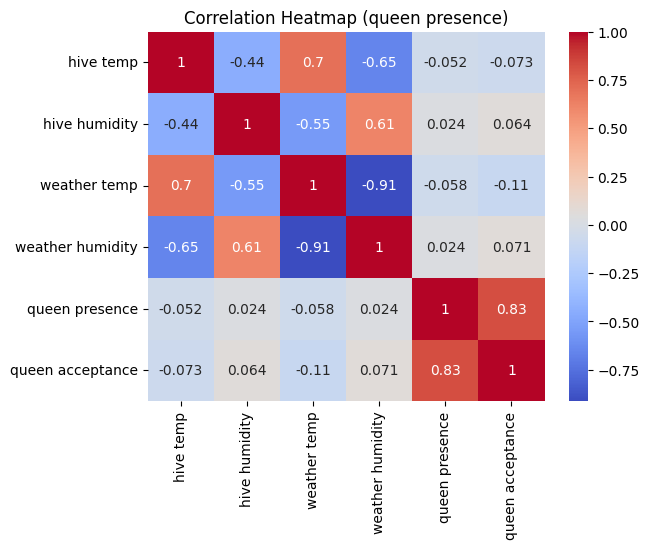


📈 Chi-squared Test Results:
hive temp: chi2 = 14.34, p = 0.0002
hive humidity: chi2 = 2.61, p = 0.1064
weather temp: chi2 = 19.34, p = 0.0000
weather humidity: chi2 = 2.36, p = 0.1246
queen acceptance: chi2 = 4959.81, p = 0.0000

🌲 Feature Importances (Random Forest):
queen acceptance    0.901847
weather humidity    0.044579
weather temp        0.019263
hive humidity       0.018016
hive temp           0.016295
dtype: float64


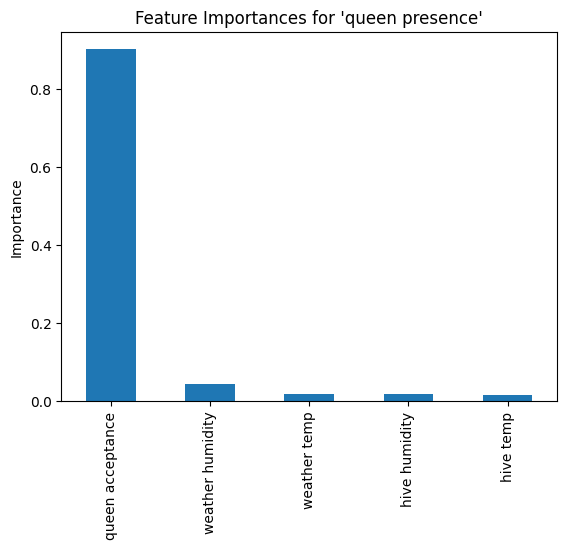


🔍 Analyzing relationships with target: queen acceptance

📊 Correlation matrix not shown for multi-class target.

📈 Chi-squared Test Results:
hive temp: chi2 = 29.14, p = 0.0000
hive humidity: chi2 = 29.69, p = 0.0000
weather temp: chi2 = 79.15, p = 0.0000
weather humidity: chi2 = 36.75, p = 0.0000
queen presence: chi2 = 5676.00, p = 0.0000

🌲 Feature Importances (Random Forest):
queen presence      0.748996
hive humidity       0.085112
weather humidity    0.060838
weather temp        0.058755
hive temp           0.046298
dtype: float64


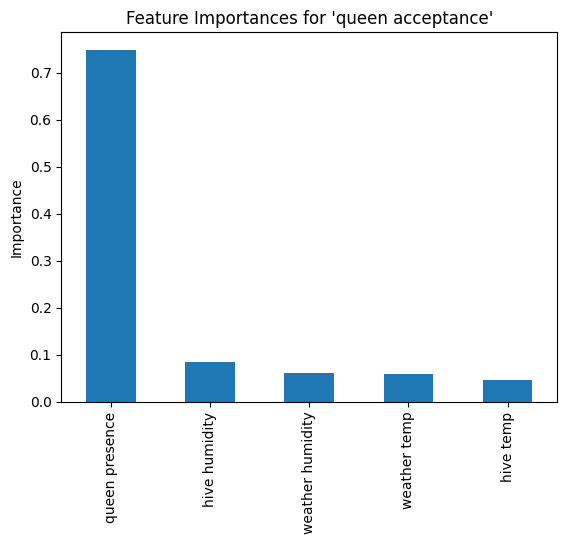

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split


# Drop columns not useful for modeling
df_clean = df.drop(columns=['file name', 'date', 'target', 'device',  'hive number'])

# Normalize numeric columns for chi2
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[df_scaled.columns] = scaler.fit_transform(df_clean[df_clean.columns])

# Function to analyze a target variable
def analyze_target_relationships(target_col):
    print(f"\n🔍 Analyzing relationships with target: {target_col}\n")

    # 1. Correlation (for numeric features)
    if df_clean[target_col].nunique() > 2:
        # For multi-class target, skip correlation
        print("📊 Correlation matrix not shown for multi-class target.")
    else:
        print("📊 Correlation with numeric features:")
        corr = df_clean.corr()[target_col].sort_values(ascending=False)
        print(corr)
        sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
        plt.title(f"Correlation Heatmap ({target_col})")
        plt.show()

    # 2. Chi-squared test (categorical vs categorical)
    print("\n📈 Chi-squared Test Results:")
    X_cat = df_scaled.drop(columns=[target_col])
    y_cat = df_clean[target_col]
    chi_vals, p_vals = chi2(X_cat, y_cat)
    for feature, score, p in zip(X_cat.columns, chi_vals, p_vals):
        print(f"{feature}: chi2 = {score:.2f}, p = {p:.4f}")

    # 3. Feature importance via Random Forest
    print("\n🌲 Feature Importances (Random Forest):")
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    model = RandomForestClassifier(n_estimators=50, max_depth=5)
    model.fit(X_train, y_train)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)
    print(importances)

    # Plot feature importance
    importances.plot(kind="bar", title=f"Feature Importances for '{target_col}'")
    plt.ylabel("Importance")
    plt.show()


# Analyze each of your targets
analyze_target_relationships("queen presence")
analyze_target_relationships("queen acceptance")



🔍 Class distribution for: queen presence
queen presence
1    36924
0     5676
Name: count, dtype: int64


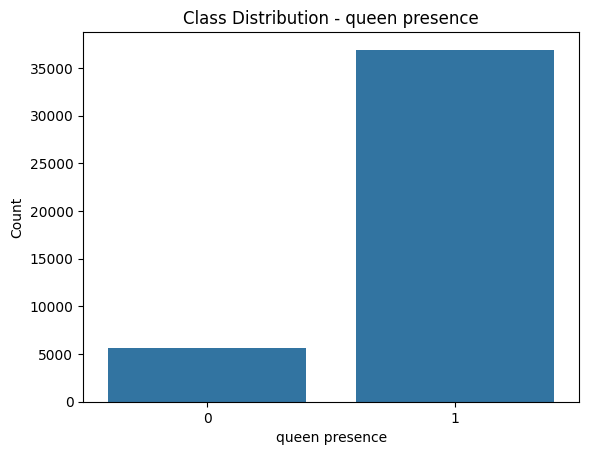


🔍 Class distribution for: queen acceptance
queen acceptance
2    27606
1     9318
0     5676
Name: count, dtype: int64


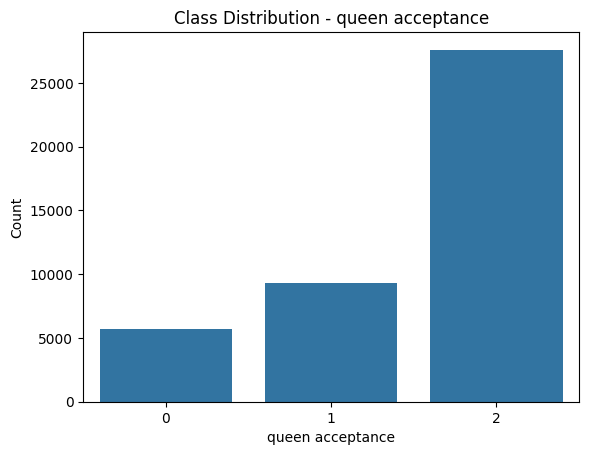

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of your target columns
target_columns = ["queen presence", "queen acceptance"]

for col in target_columns:
    print(f"\n🔍 Class distribution for: {col}")
    print(df[col].value_counts())

    # Plot the class distribution
    sns.countplot(data=df, x=col)
    plt.title(f"Class Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [44]:
import os
import librosa
import numpy as np
import pandas as pd

# Load dataset
df.columns = df.columns.str.strip()

# Path to the directory containing audio files
audio_dir = r"D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\split_audio"

# Function to extract audio features (e.g., MFCCs)
def extract_audio_features(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    return mfccs_mean

# Loop over each file and extract features
audio_features = []
failed_files = []

for fname in df['file name']:
    segment_features = []
    
    try:
        segment_path = os.path.join(audio_dir, fname)
        if os.path.exists(segment_path):
            features = extract_audio_features(segment_path)
            segment_features.append(features)
        else:
            print(f"Segment missing: {segment_path}")

        if segment_features:
            # Average features across segments
            avg_features = np.mean(segment_features, axis=0)
            audio_features.append(avg_features)
        else:
            # If no segment was found or all failed
            audio_features.append([np.nan] * 13)
            failed_files.append(fname)

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        audio_features.append([np.nan] * 13)
        failed_files.append(fname)


# Add audio features to dataframe
mfcc_df = pd.DataFrame(audio_features, columns=[f"mfcc_{i+1}" for i in range(13)])
df_combined = pd.concat([df, mfcc_df], axis=1).dropna()


In [45]:
print(df_combined)

       device  hive number            date  hive temp  hive humidity  \
0           1            5  6/10/2022 0:44      22.79          49.53   
1           1            5  6/10/2022 0:44      22.79          49.53   
2           1            5  6/10/2022 0:44      22.79          49.53   
3           1            5  6/10/2022 0:44      22.79          49.53   
4           1            5  6/10/2022 0:44      22.79          49.53   
...       ...          ...             ...        ...            ...   
42595       2            1   7/9/2022 9:56      44.91          24.96   
42596       2            1   7/9/2022 9:56      44.91          24.96   
42597       2            1   7/9/2022 9:56      44.91          24.96   
42598       2            1   7/9/2022 9:56      44.91          24.96   
42599       2            1   7/9/2022 9:56      44.91          24.96   

       weather temp  weather humidity  \
0             18.21                67   
1             18.21                67   
2           

In [46]:
df_combined.to_excel("bee_data_with_features.xlsx", index=False)


In [47]:
df_combined = pd.read_excel("bee_data_with_features.xlsx")

In [48]:
(df_combined)

,device,hive number,date,hive temp,hive humidity,weather temp,weather humidity,file name,queen presence,queen acceptance,...,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13
0,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part1.wav,1,1,...,34.537018,0.511396,16.995611,5.063058,11.616755,-0.400196,-1.472061,0.771666,-4.514010,2.321908
1,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part2.wav,1,1,...,57.559734,-17.399084,33.241402,-7.695828,20.976540,-7.154881,0.752085,0.889669,-6.246036,6.277294
2,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part3.wav,1,1,...,61.880264,-22.262655,35.416031,-12.042973,22.132504,-7.877426,3.230745,0.647448,-6.727340,6.534652
3,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part4.wav,1,1,...,62.455963,-22.801729,36.401627,-11.435645,23.498758,-8.706249,2.660795,1.163915,-6.049634,7.068784
4,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part5.wav,1,1,...,60.645962,-22.078533,35.674858,-10.475163,23.114126,-7.895323,1.774674,0.579147,-6.307888,6.722559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42595,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part2.wav,1,2,...,52.643635,-21.016586,31.196920,-12.523530,18.737366,-6.216877,-6.605219,-1.945266,-11.247485,6.812871
42596,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part3.wav,1,2,...,52.577229,-20.953497,31.198210,-12.464167,18.735512,-6.247052,-6.627166,-1.912710,-11.199468,6.809217
42597,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part4.wav,1,2,...,52.866745,-21.200775,31.267803,-12.569553,18.809698,-6.156178,-6.542924,-1.820260,-11.344868,6.759151
42598,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part5.wav,1,2,...,52.964607,-21.190672,31.409008,-12.648066,18.854597,-6.362809,-6.639550,-1.865952,-11.218760,6.916829


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report


# Drop non-numeric/unnecessary for model inputs
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])
y = df_combined["queen presence"]  # or "queen acceptance", etc.

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use a simple model (can be replaced with LightGBM or others)
clf1 = DecisionTreeClassifier(max_depth=5)
clf1.fit(X_train, y_train)

# Evaluate
y_pred = clf1.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.88      0.27      0.42      1105
           1       0.90      0.99      0.95      7415

    accuracy                           0.90      8520
   macro avg       0.89      0.63      0.68      8520
weighted avg       0.90      0.90      0.88      8520



In [50]:
print(X)

       hive temp  hive humidity  weather temp  weather humidity      mfcc_1  \
0          22.79          49.53         18.21                67 -253.075516   
1          22.79          49.53         18.21                67 -277.391571   
2          22.79          49.53         18.21                67 -282.640442   
3          22.79          49.53         18.21                67 -280.645081   
4          22.79          49.53         18.21                67 -278.689636   
...          ...            ...           ...               ...         ...   
42595      44.91          24.96         21.32                66 -237.369110   
42596      44.91          24.96         21.32                66 -237.285858   
42597      44.91          24.96         21.32                66 -237.225311   
42598      44.91          24.96         21.32                66 -237.553329   
42599      44.91          24.96         21.32                66 -237.936234   

           mfcc_2     mfcc_3     mfcc_4     mfcc_5 

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Drop non-numeric/unnecessary for model inputs
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])
y = df_combined["queen acceptance"]  # or "queen acceptance", etc.

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use a simple model (can be replaced with LightGBM or others)
clf2 = DecisionTreeClassifier(max_depth=5)
clf2.fit(X_train, y_train)

# Evaluate
y_pred = clf2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.61      0.25      0.36      1105
           1       0.71      0.48      0.57      1923
           2       0.77      0.95      0.85      5492

    accuracy                           0.75      8520
   macro avg       0.70      0.56      0.59      8520
weighted avg       0.73      0.75      0.72      8520



In [52]:
print(X)

       hive temp  hive humidity  weather temp  weather humidity      mfcc_1  \
0          22.79          49.53         18.21                67 -253.075516   
1          22.79          49.53         18.21                67 -277.391571   
2          22.79          49.53         18.21                67 -282.640442   
3          22.79          49.53         18.21                67 -280.645081   
4          22.79          49.53         18.21                67 -278.689636   
...          ...            ...           ...               ...         ...   
42595      44.91          24.96         21.32                66 -237.369110   
42596      44.91          24.96         21.32                66 -237.285858   
42597      44.91          24.96         21.32                66 -237.225311   
42598      44.91          24.96         21.32                66 -237.553329   
42599      44.91          24.96         21.32                66 -237.936234   

           mfcc_2     mfcc_3     mfcc_4     mfcc_5 


📌 Evaluating Model for: Queen Acceptance

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.25      0.36      1105
           1       0.71      0.48      0.57      1923
           2       0.77      0.95      0.85      5492

    accuracy                           0.75      8520
   macro avg       0.70      0.56      0.59      8520
weighted avg       0.73      0.75      0.72      8520



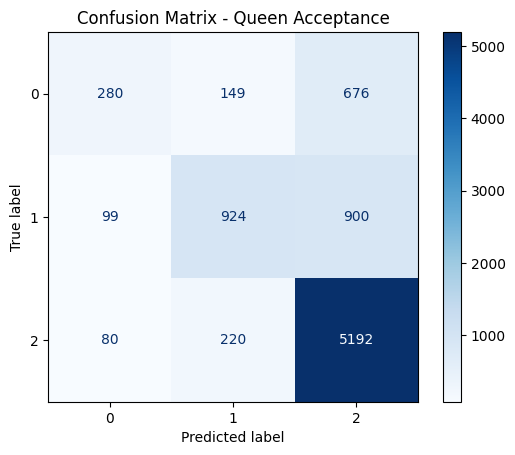


📌 Evaluating Model for: Queen Presence

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.27      0.42      1105
           1       0.90      0.99      0.95      7415

    accuracy                           0.90      8520
   macro avg       0.89      0.63      0.68      8520
weighted avg       0.90      0.90      0.88      8520



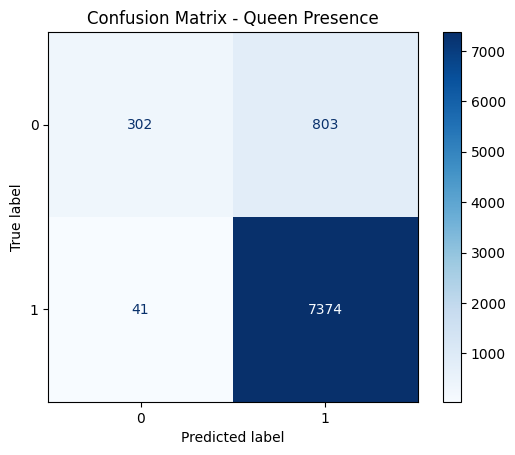

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Shared input features
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])

# Define targets
targets = {
    "Queen Acceptance": df_combined["queen acceptance"],
    "Queen Presence": df_combined["queen presence"]
}

for model_name, y in targets.items():
    print(f"\n📌 Evaluating Model for: {model_name}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Evaluation Report
    print("\n🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


In [54]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select only MFCC features
all_features = df_combined[
    ["hive temp", "hive humidity", "weather temp", "weather humidity"] +
    [f"mfcc_{i}" for i in range(1, 14)]
]
# Remove any missing values
all_features = all_features.dropna()

# Fit Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df_combined['anomaly'] = iso_forest.fit_predict(all_features)

# Anomalies are marked as -1, normal as 1
df_combined['anomaly_label'] = df_combined['anomaly'].map({1: "Normal", -1: "Anomaly"})

# Count anomalies
print(df_combined['anomaly_label'].value_counts())

anomaly_label
Normal     40470
Anomaly     2130
Name: count, dtype: int64


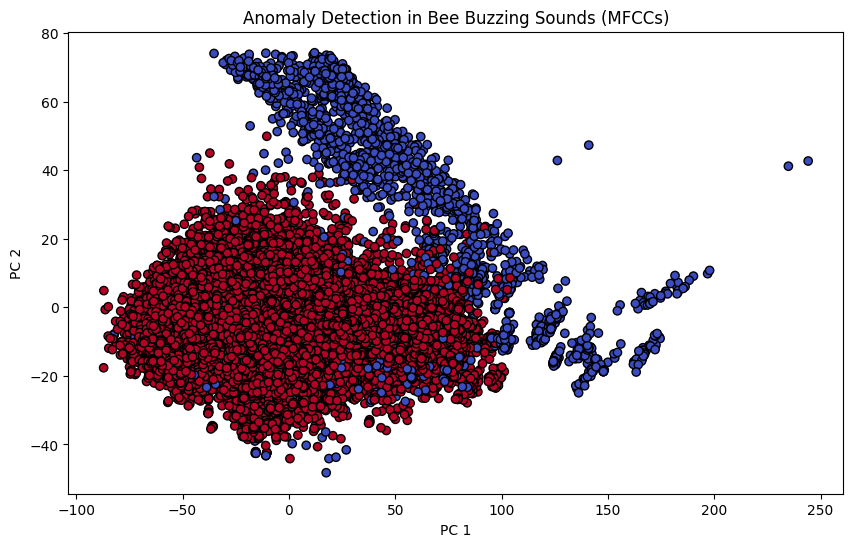

In [55]:
# Reduce to 2D for visualization
pca = PCA(n_components=2)
components = pca.fit_transform(all_features)

plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], c=df_combined['anomaly'], cmap='coolwarm', edgecolor='k')
plt.title('Anomaly Detection in Bee Buzzing Sounds (MFCCs)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()


In [56]:
anomalous_files = df_combined[df_combined['anomaly_label'] == "Anomaly"]['file name'].tolist()
print("Anomalous Audio Files:", anomalous_files)


Anomalous Audio Files: ['2022-06-10--00-44-04_1__segment0_part1.wav', '2022-06-10--00-44-16_2__segment0_part1.wav', '2022-06-10--01-43-17_1__segment0_part1.wav', '2022-06-10--01-43-29_2__segment0_part1.wav', '2022-06-10--10-37-28_1__segment0_part1.wav', '2022-06-10--10-37-17_2__segment0_part1.wav', '2022-06-10--10-37-17_2__segment1_part4.wav', '2022-06-10--11-36-55_1__segment0_part1.wav', '2022-06-10--11-36-55_1__segment2_part5.wav', '2022-06-10--11-36-55_1__segment2_part6.wav', '2022-06-10--11-36-55_1__segment3_part1.wav', '2022-06-10--11-36-55_1__segment3_part2.wav', '2022-06-10--11-36-55_1__segment3_part4.wav', '2022-06-10--11-36-55_1__segment3_part5.wav', '2022-06-10--11-36-55_1__segment4_part1.wav', '2022-06-10--11-36-55_1__segment4_part2.wav', '2022-06-10--11-36-55_1__segment4_part3.wav', '2022-06-10--11-36-55_1__segment4_part4.wav', '2022-06-10--11-36-55_1__segment5_part1.wav', '2022-06-10--11-36-55_1__segment5_part2.wav', '2022-06-10--11-36-55_1__segment5_part3.wav', '2022-06-1

In [57]:
df_combined

,device,hive number,date,hive temp,hive humidity,weather temp,weather humidity,file name,queen presence,queen acceptance,...,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,anomaly,anomaly_label
0,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part1.wav,1,1,...,16.995611,5.063058,11.616755,-0.400196,-1.472061,0.771666,-4.514010,2.321908,-1,Anomaly
1,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part2.wav,1,1,...,33.241402,-7.695828,20.976540,-7.154881,0.752085,0.889669,-6.246036,6.277294,1,Normal
2,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part3.wav,1,1,...,35.416031,-12.042973,22.132504,-7.877426,3.230745,0.647448,-6.727340,6.534652,1,Normal
3,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part4.wav,1,1,...,36.401627,-11.435645,23.498758,-8.706249,2.660795,1.163915,-6.049634,7.068784,1,Normal
4,1,5,6/10/2022 0:44,22.79,49.53,18.21,67,2022-06-10--00-44-04_1__segment0_part5.wav,1,1,...,35.674858,-10.475163,23.114126,-7.895323,1.774674,0.579147,-6.307888,6.722559,1,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42595,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part2.wav,1,2,...,31.196920,-12.523530,18.737366,-6.216877,-6.605219,-1.945266,-11.247485,6.812871,1,Normal
42596,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part3.wav,1,2,...,31.198210,-12.464167,18.735512,-6.247052,-6.627166,-1.912710,-11.199468,6.809217,1,Normal
42597,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part4.wav,1,2,...,31.267803,-12.569553,18.809698,-6.156178,-6.542924,-1.820260,-11.344868,6.759151,1,Normal
42598,2,1,7/9/2022 9:56,44.91,24.96,21.32,66,2022-07-09--09-56-11_2__segment5_part5.wav,1,2,...,31.409008,-12.648066,18.854597,-6.362809,-6.639550,-1.865952,-11.218760,6.916829,1,Normal


In [58]:
import joblib


joblib.dump(clf1, 'queen_presence_model.pkl')
joblib.dump(clf2, 'queen_acceptance_model.pkl')
joblib.dump(iso_forest, 'bee_sound_anomaly_model.pkl')

['bee_sound_anomaly_model.pkl']